<a href="https://colab.research.google.com/github/ORACHPAULFRANCIS/borderlessmaps/blob/main/Geocode2025PythonWebinaripynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# Import necessary libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import plotly.express as px
import shapely

In [39]:
# Read imported data
population_size = gpd.read_file(r'/content/Population Size & Headship of Households by Sex---Parish Level.shp')

In [40]:
# View info
population_size.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7506 entries, 0 to 7505
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         7506 non-null   int64   
 1   objectid    7506 non-null   int64   
 2   d           7506 non-null   object  
 3   c           7506 non-null   object  
 4   s           7506 non-null   object  
 5   pname       7506 non-null   object  
 6   mpopn       7506 non-null   int64   
 7   fpopn       7506 non-null   int64   
 8   sexratio    7506 non-null   float64 
 9   tpopn       7506 non-null   int64   
 10  mhhead      7506 non-null   int64   
 11  %Mhhead     7506 non-null   float64 
 12  fhhead      7506 non-null   int64   
 13  %Fhhead     7506 non-null   float64 
 14  HhHd(10-17  7506 non-null   int64   
 15  %HhH(10-17  7506 non-null   float64 
 16  Hd(18-30)   7506 non-null   int64   
 17  %(18-30)    7506 non-null   float64 
 18  Hd+60       7506 non-null   int64   
 19

In [41]:
# View head
population_size.head()

,gid,objectid,d,c,s,pname,mpopn,fpopn,sexratio,tpopn,...,fhhead,%Fhhead,HhHd(10-17,%HhH(10-17,Hd(18-30),%(18-30),Hd+60,%Hd+60,popntotal,geometry
0,6,3507,KASESE,BUKONZO,KARAMBI,BUHUNA,1759,1918,91.7,3677,...,149,22.3,2,0.3,160,24.0,106,15.9,667,"POLYGON ((139184.957 10007123.835, 139359.598 ..."
1,12,3511,MITOOMA,RUHINDA,KASHENSHERO TOWN COUNCIL,WARD I,743,822,90.4,1565,...,91,26.1,1,0.3,72,20.7,62,17.8,348,"POLYGON ((164126.601 9931244.014, 164111.159 9..."
2,14,6560,MBALE,BUNGOKHO,NAKALOKE,DOKO,1697,1899,89.4,3596,...,182,24.6,2,0.3,173,23.3,139,18.8,741,"POLYGON ((629871.173 10123742.615, 629866.122 ..."
3,17,5569,BUGIRI,BUKOOLI,NANKOMA,ISEGERO,2575,2761,93.3,5336,...,170,17.9,1,0.1,243,25.5,178,18.7,952,"POLYGON ((569714.811 10050229.843, 569512.484 ..."
4,34,1932,KITGUM,CHUA,NAMOKORA,PAGWOK,2518,2620,96.1,5138,...,217,22.9,1,0.1,180,19.0,207,21.8,949,"POLYGON ((538324.335 10377727.837, 538398.336 ..."


In [42]:
# View description
population_size.describe()

,gid,objectid,mpopn,fpopn,sexratio,tpopn,mhhead,%Mhhead,fhhead,%Fhhead,HhHd(10-17,%HhH(10-17,Hd(18-30),%(18-30),Hd+60,%Hd+60,popntotal
count,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000,7506.00000,7506.000000,7506.000000,7506.000000,7506.000000,7506.000000
mean,3753.500000,3943.456035,2245.957900,2357.463363,97.133133,4603.421263,736.850919,77.029976,233.934586,22.970171,4.751799,0.45373,277.220757,25.757994,143.016254,16.754876,970.785505
std,2166.939893,2340.650174,2064.594426,2290.111618,10.817881,4347.462637,797.548141,6.038042,301.242687,6.038105,7.353423,0.45911,448.988302,6.608942,94.349702,5.343161,1084.705732
min,1.000000,1.000000,39.000000,26.000000,35.000000,65.000000,3.000000,21.300000,1.000000,4.500000,0.000000,0.00000,3.000000,8.200000,0.000000,0.000000,6.000000
25%,1877.250000,1949.500000,1165.000000,1200.250000,91.900000,2360.250000,364.000000,73.100000,100.000000,18.800000,1.000000,0.20000,109.000000,21.200000,76.000000,13.800000,476.000000
50%,3753.500000,3909.500000,1790.000000,1859.500000,95.800000,3647.000000,567.000000,77.300000,168.000000,22.700000,3.000000,0.40000,183.000000,24.800000,122.000000,17.100000,740.000000
75%,5629.750000,5856.750000,2693.000000,2838.000000,100.500000,5539.750000,864.000000,81.200000,267.000000,26.900000,6.000000,0.60000,294.000000,29.200000,188.000000,20.100000,1125.750000
max,7506.000000,9786.000000,45834.000000,52061.000000,365.200000,97895.000000,19855.000000,95.500000,7018.000000,78.700000,148.000000,9.20000,11895.000000,72.500000,1043.000000,47.600000,26873.000000


In [43]:
# View columns
population_size.columns

Index(['gid', 'objectid', 'd', 'c', 's', 'pname', 'mpopn', 'fpopn', 'sexratio',
       'tpopn', 'mhhead', '%Mhhead', 'fhhead', '%Fhhead', 'HhHd(10-17',
       '%HhH(10-17', 'Hd(18-30)', '%(18-30)', 'Hd+60', '%Hd+60', 'popntotal',
       'geometry'],
      dtype='object')

In [44]:
# Confirm CRS
population_size.crs

<Projected CRS: EPSG:21036>
Name: Arc 1960 / UTM zone 36S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Kenya - south of equator and west of 36°E; Tanzania - 30°E to 36°E; Uganda - south of equator and east of 30°E.
- bounds: (29.99, -11.61, 36.0, 0.01)
Coordinate Operation:
- name: UTM zone 36S
- method: Transverse Mercator
Datum: Arc 1960
- Ellipsoid: Clarke 1880 (RGS)
- Prime Meridian: Greenwich

In [45]:
# Change CRS to match Uganda WGS 1984 UTM Zone 36N
population_size = population_size.to_crs(epsg=32636)

In [46]:
# Check new CRS
population_size.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [47]:
# Rename colums
population_size = population_size.rename(columns={'d': 'District', 'c' : 'County', 'pname' : 'Parish_name', 'mpopn' : 'male_population', 's' : 'SubCounty', 'fpopn': 'female_population'})

In [51]:
# Review columns
population_size.columns

Index(['gid', 'objectid', 'District', 'County', 'SubCounty', 'Parish_name',
       'male_population', 'female_population', 'sexratio', 'tpopn', 'mhhead',
       '%Mhhead', 'fhhead', '%Fhhead', 'HhHd(10-17', '%HhH(10-17', 'Hd(18-30)',
       '%(18-30)', 'Hd+60', '%Hd+60', 'popntotal', 'geometry'],
      dtype='object')

In [53]:
# Remove columns not necessary for our analysis
population_size = population_size.drop(columns=['mhhead', '%Mhhead', 'fhhead', '%Fhhead', 'HhHd(10-17', '%HhH(10-17', 'Hd(18-30)', '%(18-30)', 'Hd+60', '%Hd+60'])

In [54]:
# View columns
population_size.columns

Index(['gid', 'objectid', 'District', 'County', 'SubCounty', 'Parish_name',
       'male_population', 'female_population', 'sexratio', 'tpopn',
       'popntotal', 'geometry'],
      dtype='object')

In [55]:
print(population_size.columns)

Index(['gid', 'objectid', 'District', 'County', 'SubCounty', 'Parish_name',
       'male_population', 'female_population', 'sexratio', 'tpopn',
       'popntotal', 'geometry'],
      dtype='object')


In [60]:
# Remove popntotal column
population_size = population_size.drop(columns=['popntotal'])

# View columns
population_size.columns

Index(['gid', 'objectid', 'District', 'County', 'SubCounty', 'Parish_name',
       'male_population', 'female_population', 'tpopn', 'geometry'],
      dtype='object')

In [61]:
# View head
population_size.head()

,gid,objectid,District,County,SubCounty,Parish_name,male_population,female_population,tpopn,geometry
0,6,3507,KASESE,BUKONZO,KARAMBI,BUHUNA,1759,1918,3677,"POLYGON ((139265.602 6821.496, 139440.245 6520..."
1,12,3511,MITOOMA,RUHINDA,KASHENSHERO TOWN COUNCIL,WARD I,743,822,1565,"POLYGON ((164207.532 -69058.536, 164192.089 -6..."
2,14,6560,MBALE,BUNGOKHO,NAKALOKE,DOKO,1697,1899,3596,"POLYGON ((629955.511 123444.129, 629950.46 123..."
3,17,5569,BUGIRI,BUKOOLI,NANKOMA,ISEGERO,2575,2761,5336,"POLYGON ((569797.192 49928.154, 569594.864 498..."
4,34,1932,KITGUM,CHUA,NAMOKORA,PAGWOK,2518,2620,5138,"POLYGON ((538406.679 377428.015, 538480.681 37..."


In [65]:
# Add a column called Area and use it to calculate the area of the polygons in square kilometers
population_size['Area'] = population_size['geometry'].area / 10**6

In [67]:
# View heads
population_size.head()

,gid,objectid,District,County,SubCounty,Parish_name,male_population,female_population,tpopn,geometry,Area
0,6,3507,KASESE,BUKONZO,KARAMBI,BUHUNA,1759,1918,3677,"POLYGON ((139265.602 6821.496, 139440.245 6520...",2.256132
1,12,3511,MITOOMA,RUHINDA,KASHENSHERO TOWN COUNCIL,WARD I,743,822,1565,"POLYGON ((164207.532 -69058.536, 164192.089 -6...",3.417352
2,14,6560,MBALE,BUNGOKHO,NAKALOKE,DOKO,1697,1899,3596,"POLYGON ((629955.511 123444.129, 629950.46 123...",6.615562
3,17,5569,BUGIRI,BUKOOLI,NANKOMA,ISEGERO,2575,2761,5336,"POLYGON ((569797.192 49928.154, 569594.864 498...",11.731055
4,34,1932,KITGUM,CHUA,NAMOKORA,PAGWOK,2518,2620,5138,"POLYGON ((538406.679 377428.015, 538480.681 37...",164.015992


In [68]:
# Calculate Population Density (PopnDen)
population_size['PopnDen'] = population_size['tpopn'] / population_size['Area']

In [69]:
# View heads
population_size.head()

,gid,objectid,District,County,SubCounty,Parish_name,male_population,female_population,tpopn,geometry,Area,PopnDen
0,6,3507,KASESE,BUKONZO,KARAMBI,BUHUNA,1759,1918,3677,"POLYGON ((139265.602 6821.496, 139440.245 6520...",2.256132,1629.780536
1,12,3511,MITOOMA,RUHINDA,KASHENSHERO TOWN COUNCIL,WARD I,743,822,1565,"POLYGON ((164207.532 -69058.536, 164192.089 -6...",3.417352,457.956925
2,14,6560,MBALE,BUNGOKHO,NAKALOKE,DOKO,1697,1899,3596,"POLYGON ((629955.511 123444.129, 629950.46 123...",6.615562,543.566811
3,17,5569,BUGIRI,BUKOOLI,NANKOMA,ISEGERO,2575,2761,5336,"POLYGON ((569797.192 49928.154, 569594.864 498...",11.731055,454.861058
4,34,1932,KITGUM,CHUA,NAMOKORA,PAGWOK,2518,2620,5138,"POLYGON ((538406.679 377428.015, 538480.681 37...",164.015992,31.326214


<Axes: >

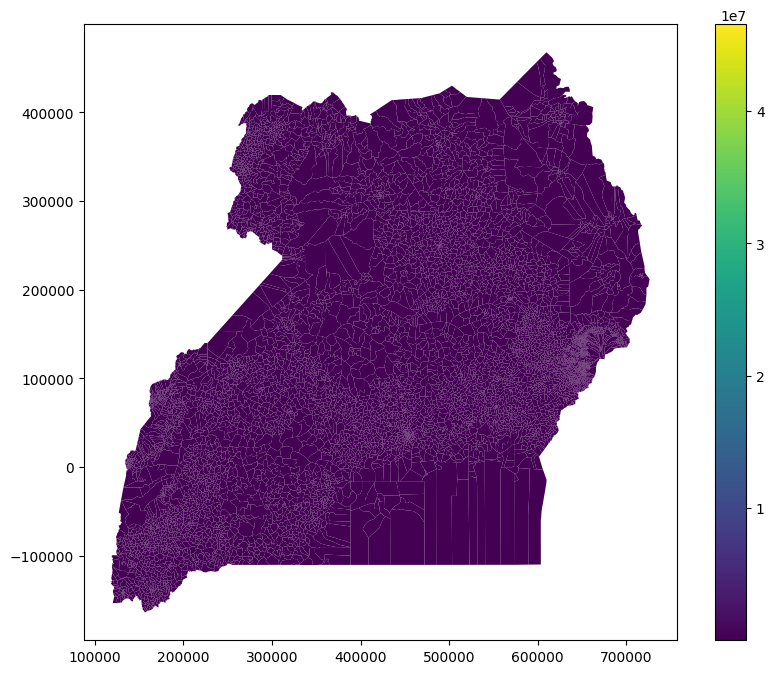

In [72]:
# Plot Population Density using matplotlip
population_size.plot(column='PopnDen', legend=True, figsize=(10, 8))

(np.float64(88032.29690786285),
 np.float64(756552.4514902744),
 np.float64(-195581.47095119682),
 np.float64(499362.8208328125))

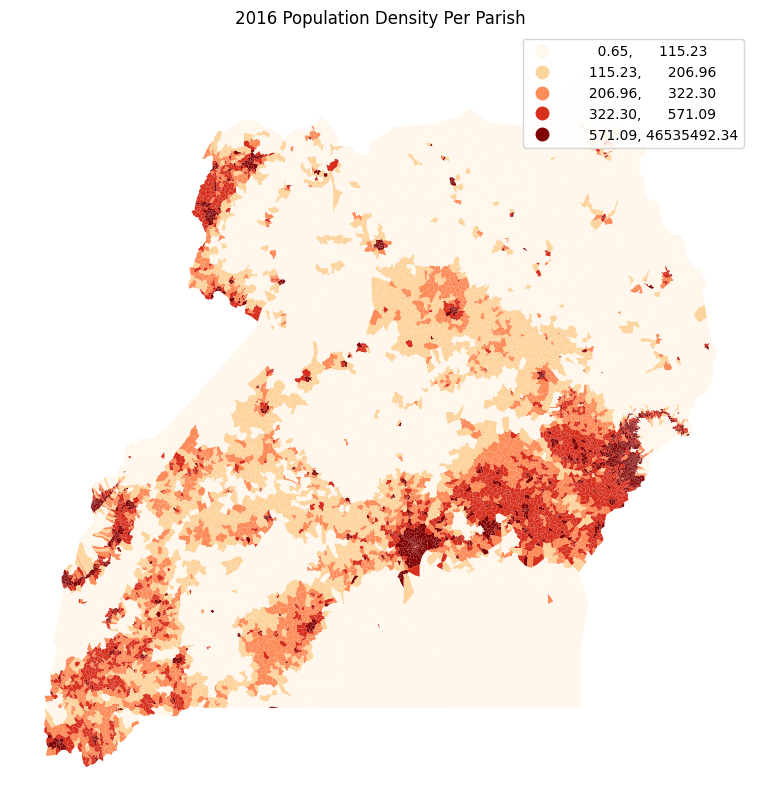

In [77]:
# Customize visuals for clarity
!pip install mapclassify
import mapclassify
population_size.plot(
column='PopnDen',
    cmap='OrRd', # Red color ramp
    legend=True,
    scheme='quantiles', # Use quantiles for classification
    figsize=(12, 10)
)
plt.title('2016 Population Density Per Parish')
plt.axis('off') # Hide axes for cleaner map

In [78]:
# Save your plot
plt.savefig('population_density_map.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [81]:
import folium

# Approximate center of Uganda (Latitude, Longitude)
# Using a common approximation from geographic data
uganda_center = [1.37, 32.30]

# Create a folium map centered on Uganda
uganda_map = folium.Map(location=uganda_center, zoom_start=8) # Increase zoom for better view

# You can then display the map
uganda_map


In [ ]:
# Add the GeoDataFrame to the map, coloring by Population Density
folium.GeoJson(
    population_size,
    name='Uganda Population Density Per Parish',
    style_function=lambda x: {
        'fillColor': '#%02x%02x%02x' % (
            int(255 * (x['properties']['PopnDen'] / population_size['PopnDen'].max())),
            0,
            0
        ), # Simple red scale based on density
        'color': 'red',
        'weight': 0.5,
        'fillOpacity': 0.7
    }
).add_to(uganda_map)

# Display map
uganda_map